# EDA — TXL-PBC (Object Detection)

**Nguồn**: GitHub `lugan113/TXL-PBC_Dataset` — gộp/tái gán nhãn từ BCCD, BCDD, PBC Barcelona, Raabin-WBC.

**Nội dung**: `Data/images/txl_pbc_repo/TXL-PBC/` — 1.260 ảnh, 18.143 bounding box dạng YOLO, 3 lớp: WBC(0)/RBC(1)/Platelet(2), chia sẵn train/val/test.

Đây là bài toán **detection** (định vị+đếm), khác bản chất với 2 bộ ảnh classification kia.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

plt.rcParams['figure.figsize'] = (10, 5)
ROOT = Path(r'D:\AI_08_V1\Data\images\txl_pbc_repo\TXL-PBC')
IMG_EXT = {'.jpg', '.jpeg', '.png'}
class_names = {'0': 'WBC', '1': 'RBC', '2': 'Platelet'}

rows = []
for split in ['train', 'val', 'test']:
    img_dir, lbl_dir = ROOT / 'images' / split, ROOT / 'labels' / split
    n_img = sum(1 for f in img_dir.iterdir() if f.suffix.lower() in IMG_EXT)
    counter = Counter()
    n_boxes = 0
    for lbl_file in lbl_dir.glob('*.txt'):
        lines = [l for l in lbl_file.read_text(encoding='utf-8', errors='ignore').splitlines() if l.strip()]
        n_boxes += len(lines)
        for line in lines:
            counter[class_names.get(line.split()[0], line.split()[0])] += 1
    rows.append({'split': split, 'n_images': n_img, 'n_boxes': n_boxes, **counter})

summary = pd.DataFrame(rows).set_index('split')
summary

,n_images,n_boxes,RBC,WBC,Platelet
split,,,,,
train,882,12510,11220,908,382
val,252,3752,3383,257,112
test,126,1881,1699,133,49


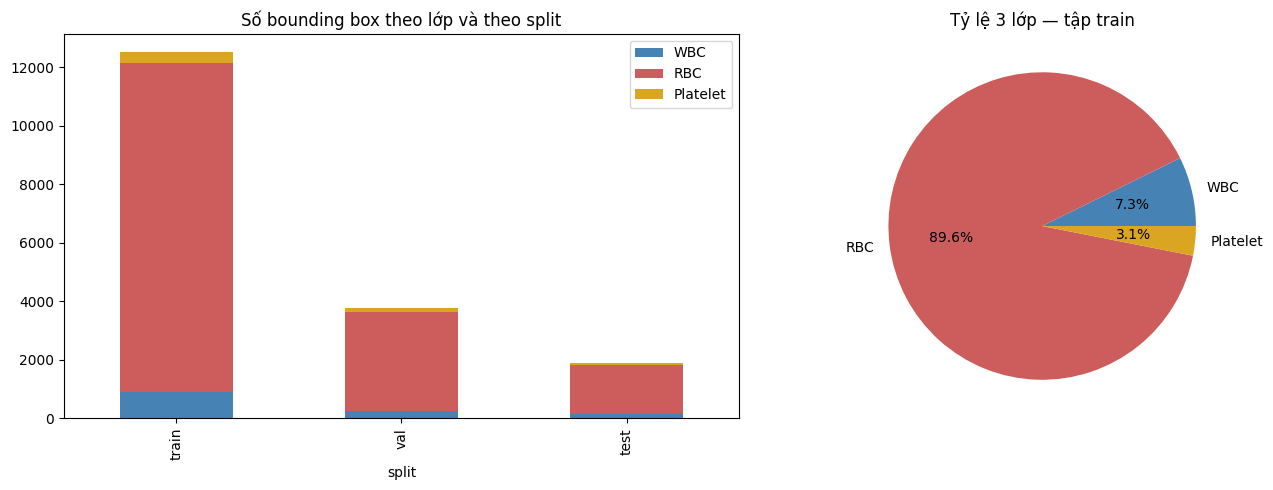

WBC          7.3
RBC         89.7
Platelet     3.1
Name: train, dtype: float64


In [2]:
# Biểu đồ tỷ lệ 3 lớp trong tập train + 1 ảnh mẫu có vẽ bounding box
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
summary[['WBC', 'RBC', 'Platelet']].plot.bar(ax=axes[0], stacked=True, color=['steelblue', 'indianred', 'goldenrod'])
axes[0].set_title('Số bounding box theo lớp và theo split')

train_pct = (summary.loc['train', ['WBC', 'RBC', 'Platelet']] / summary.loc['train', 'n_boxes'] * 100).round(1)
train_pct.plot.pie(ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'indianred', 'goldenrod'])
axes[1].set_title('Tỷ lệ 3 lớp — tập train')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()
print(train_pct)

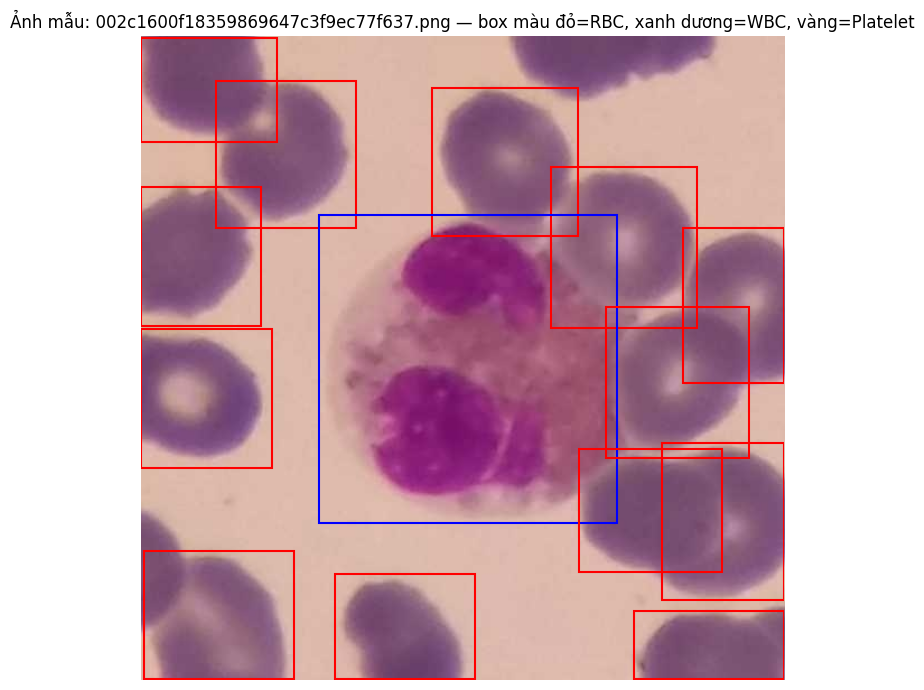

In [3]:
# Minh hoạ 1 ảnh mẫu kèm bounding box vẽ đè lên
from PIL import Image
import matplotlib.patches as patches

img_dir, lbl_dir = ROOT / 'images' / 'train', ROOT / 'labels' / 'train'
sample_img = next(img_dir.iterdir())
sample_lbl = lbl_dir / (sample_img.stem + '.txt')

img = Image.open(sample_img)
w, h = img.size
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img)
colors = {'0': 'blue', '1': 'red', '2': 'gold'}
for line in sample_lbl.read_text().splitlines():
    if not line.strip():
        continue
    cls, xc, yc, bw, bh = line.split()
    xc, yc, bw, bh = float(xc)*w, float(yc)*h, float(bw)*w, float(bh)*h
    rect = patches.Rectangle((xc-bw/2, yc-bh/2), bw, bh, linewidth=1.5, edgecolor=colors.get(cls,'green'), facecolor='none')
    ax.add_patch(rect)
ax.set_title(f'Ảnh mẫu: {sample_img.name} — box màu đỏ=RBC, xanh dương=WBC, vàng=Platelet')
ax.axis('off')
plt.tight_layout()
plt.show()

## Nhận xét

- RBC chiếm ~89.7% số box trong tập train, WBC ~7.3%, Platelet ~3% — RBC áp đảo hoàn toàn (đúng thực tế sinh học), cần class weighting/loss balancing khi huấn luyện detection.
- Chỉ phân biệt 3 loại tế bào lớn, không phân loại tiếp neutrophil/eosinophil/lymphocyte... — muốn chi tiết hơn phải dùng nguồn khác (Raabin, PBC Barcelona).
- Bài toán detection khác bản chất với 2 bộ ảnh classification còn lại — không gộp trực tiếp cùng 1 pipeline huấn luyện.